<h1 style="text-align: center;">
    🎲 Sampling from Static Distributions
</h1>

This notebook demonstrates how to create distributions from a series of functions using `streamgen`.

First, we will create one background and two class signals using `numpy`.
Then, we will demonstrate how to use the `SamplingTree` class to sample from these distributions.
Finally, we will add `ClassLabelNode`s, which will allow us to sample labeled signals.

---

## 📄 Table of Contents

1. [🧮 Function based data generation](#🧮-function-based-data-generation)
2. [🌳 Sampling trees](#🌳-sampling-trees)
3. [🏷️ Generating labels](#🏷️-generating-labels)

In [1]:
from pathlib import Path

import numpy as np
from numpy.random import Generator
import seaborn as sns
from rich import print

from streamgen import visualizations
from streamgen.nodes import SampleBufferNode
from streamgen.samplers.tree import SamplingTree
from streamgen.transforms import noop

SEED = 42
rng = np.random.default_rng(SEED)

sns.set_theme()

output_path = Path("./")
output_path.mkdir(parents=True, exist_ok=True)

## 🧮 Function based data 

We want to generate a dataset of time series.
This dataset consists of three classes with the following parameters:

1. 🎵 **"background"** - background noise from our measurement equipment
    - ⚙️ `signal_length` - how many measurement points are in our signal 
    - ⚙️ `offset` - signal offset of the background noise 
    - ⚙️ `strength` - signal strength of the background noise 
2. 🪜 **"ramp"** - a slowly climbing ramp signal
    - ⚙️ `height` - height of the ramp 
    - ⚙️ `length` - length of the ramp
3. 🏃 **"step"** - a step signal
    - ⚙️ `length` - length of the step 
    - ⚙️ `kernel_size` - kernel size for a moving average filtering

> 🎲 to foster reproducibility, a common practice when using `streamgen` is to use a random number generator (`numpy.random.Generator`) from the functions keyword arguments. we use the pattern `... some_arg: str, *, rng: Generator` to annotate the keyword argument `rng` without a default value. Alternatively, one could use a default value of `None`, which will lead to a crash when not passing in a correct `Generator` object.

In [2]:
def background(signal_, signal_length: int, offset: float, strength: float, *, rng: Generator) -> np.ndarray:  # noqa: D103, ANN001, ARG001
    return rng.normal(offset, strength, signal_length)


def ramp(signal: np.ndarray, height: float, length: int, *, rng: Generator) -> np.ndarray:  # noqa: D103
    ramp_signal = np.zeros(len(signal))
    ramp_start = rng.choice(range(len(signal) - length))
    ramp_signal[ramp_start : ramp_start + length] = np.linspace(0.0, height, length)
    return signal + ramp_signal


def step(signal: np.ndarray, length: int, kernel_size: int, *, rng: Generator) -> np.ndarray:  # noqa: D103
    step_signal = np.zeros(len(signal))
    step_start = rng.choice(range(len(signal) - length))
    step_signal[step_start : step_start + length] = 1.0
    kernel = np.ones(kernel_size) / kernel_size
    step_signal = np.convolve(step_signal, kernel, mode="same")
    return signal + step_signal

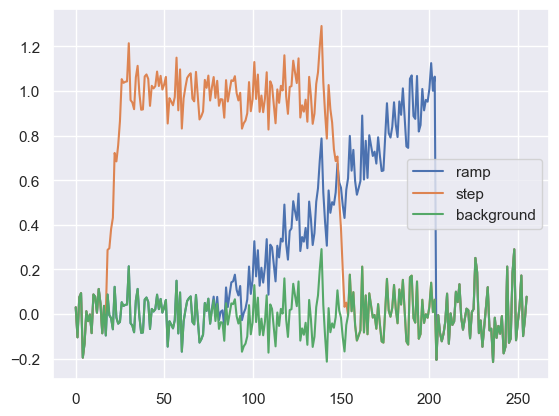

In [3]:
%matplotlib inline

# ⚙️ parameters
signal_length = 256
offset = 0.0
noise_strength = 0.1
height = 1.0
length = 128
kernel_size = 10

# 🎲 sample signals
background_sample = background(None, signal_length, offset, noise_strength, rng=rng)
ramp_sample = ramp(background_sample, height, length, rng=rng)
step_sample = step(background_sample, length, kernel_size, rng=rng)

# 📈 plot signals
sns.lineplot(ramp_sample, label="ramp")
sns.lineplot(step_sample, label="step")
sns.lineplot(background_sample, label="background");

## 🌳 Sampling trees

In the last section, we manually sampled from our three signal generation functions.

This approach has a few shortcomings:

+ for each sample, one has to call the corresponding function by hand 🖐️
+ the parameter handling is a bit awkward and clumsy (parameter to function association is not clear)
+ dependencies (like `step` and `ramp` requiring `background` as input) are not clear

To address all of these issues, `streamgen` provides the `SamplingTree` class, which organizes and calls functions very similar to `torchvision.transforms.Compose` or `torch.nn.Sequential`:

```python
from torchvision.transforms import v2

transforms = v2.Compose([
    v2.RandomHorizontalFlip(),
    v2.RandomResizedCrop(size=(224, 224), antialias=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    # ...
])

while generating_data:
    sample = np.random.randn(...)
    augmented_sample = transforms(sample)
    # -> sample is passed to the first function in transforms.
    # the output if this transform si then passed as input to the next transform ...
```

Instead of using a sequential organization of functions, `streamgen` uses trees of transformations.

![sampling tree](../../docs/images/sampling_tree.png)

We use the package [anytree](https://anytree.readthedocs.io/en/latest/) and a custom `Node` class (`streamgen.nodes.TransformNode`) to construct these trees.
For convenient construction, we also provide a shorthand description following the rules:

1. Nodes are linked sequentially according to the ordering in the top-level list.
2. `TransformNode` and sub-classes are not modified.
3. `Callable`s are cast into `TransformNode`s.
4. `str` are cast into `ClassLabelNode`
5. dictionaries are interpreted as `BranchingNode`s, where each value represents a branch.
    The keys `name`, `probs` and `seed` are reserved to describe the node itself.
6. If there is a node after a `BranchingNode`, then every branch will be connected to a **copy** of this node.
    This ensures that the structure of the tree is preserved (Otherwise we would create a more generic directed acyclic graph),
    which is not supported by `anytree`.

The parameters of the functions inside a tree are stored in a `ParameterStore` object. A sampling tree fetches arguments automatically from this store. To avoid naming conflicts and to have more control, you can also use the transform names as **scopes**. Scoped parameters have precedence over top-level parameters.

> 👉 more details about parameter handling is explained in the next notebook on [🌌 data streams](./02-data-streams.ipynb).

In [4]:
# ⚙️ scoped parameter
params = {
    "background": {
        "signal_length": 256,
        "offset": 0.0,
        "strength": 0.1,
    },
    "ramp": {
        "height": 1.0,
    },
    "step": {
        "kernel_size": 10,
    },
    "length": 128, # top-level length parameter will be passed to both the `step` and `ramp` functions
}

# 🎲🌳 tree of transformations
tree = SamplingTree(
    [
        background,
        {
            "background": noop,
            "ramp": ramp,
            "step": step,
        },
    ],
    params,
    rng=rng
)

print(tree)

🌳
➡️ `background(offset=0.0, signal_length=256, strength=0.1)`
╰── 🪴 `branching_node()`
    ├── ➡️ `noop()`
    ├── ➡️ `ramp(height=1.0, length=128)`
    ╰── ➡️ `step(kernel_size=10, length=128)`

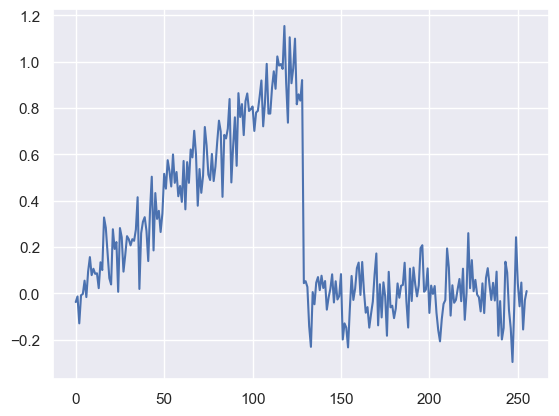

In [5]:
# 🎲 sample from tree
signal = tree.sample()
sns.lineplot(signal);

## 🏷️ Generating labels

Every path of transformations to a leaf in our sampling tree already corresponds to a "class".

To include the information about the branch into the sample, `streamgen` provides a `ClassLabelNode`, which is automatically created from strings in the tree definition.

In [6]:
# 🎲🌳 tree of transformations
tree = SamplingTree(
    [
        background,
        SampleBufferNode("background-samples"),
        {
            "background": "background",
            "ramp": [ramp, "ramp", SampleBufferNode("ramp-samples")],
            "step": [step, "step", SampleBufferNode("step-samples")],
        },
    ],
    params,
    rng=rng
)

print(tree)

🌳
➡️ `background(offset=0.0, signal_length=256, strength=0.1)`
╰── 🗃️ `background-samples()`
    ╰── 🪴 `branching_node()`
        ├── 🏷️ `background`
        ├── ➡️ `ramp(height=1.0, length=128)`
        │   ╰── 🏷️ `ramp`
        │       ╰── 🗃️ `ramp-samples()`
        ╰── ➡️ `step(kernel_size=10, length=128)`
            ╰── 🏷️ `step`
                ╰── 🗃️ `step-samples()`

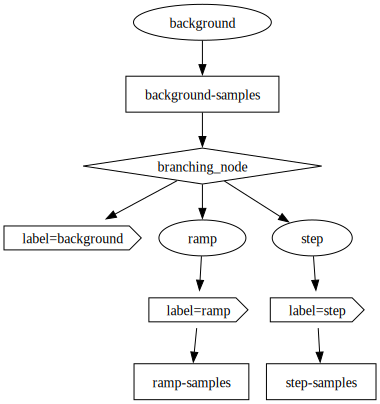

In [7]:
%matplotlib notebook


def plotting_func(sample, ax):
    ax = sns.lineplot(sample, ax=ax)
    return ax


tree.to_svg(output_path / "tree", plotting_func)

The `SampleBufferNode`s don't contain any buffered samples yet to show in the rendered graph.
After collecting some samples, the visualization will include sample plots:

Output()

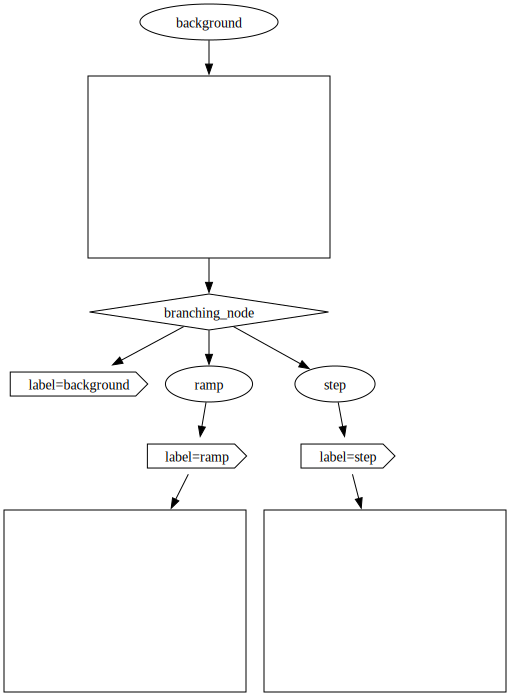

In [8]:
%matplotlib notebook
samples = tree.collect(20)

tree.to_svg(output_path / "tree_with_samples", plotting_func)

> 🥲 Unfortunately, the example gifs in the svg graph are not rendered in the hosted documentation, so we include a screen capture from the IPython interface for reference:

![output of last cell](../../docs/videos/time_series_tree_svg.gif)

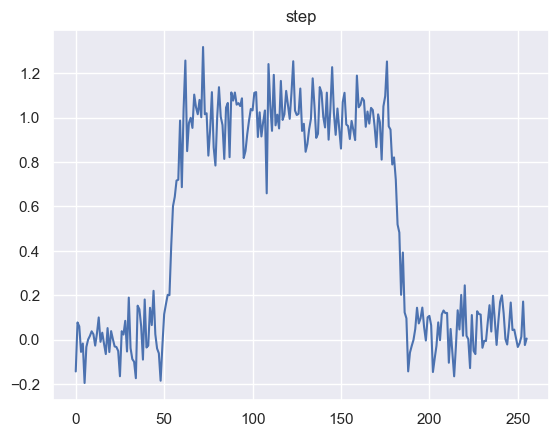

In [9]:
%matplotlib inline
# 🎲 sample from tree
signal, target = tree.sample()
sns.lineplot(signal).set_title(target);

🖼️ there are many useful visualizations in `streamgen.visualizations`.

Because any data sctructure can by generated by a user, he has to provide his own sample `plotting_func` to most of these functions.

In [10]:
%matplotlib notebook
visualizations.plot_labeled_samples_animation(tree, lambda sample, ax: sns.lineplot(sample, ax=ax))

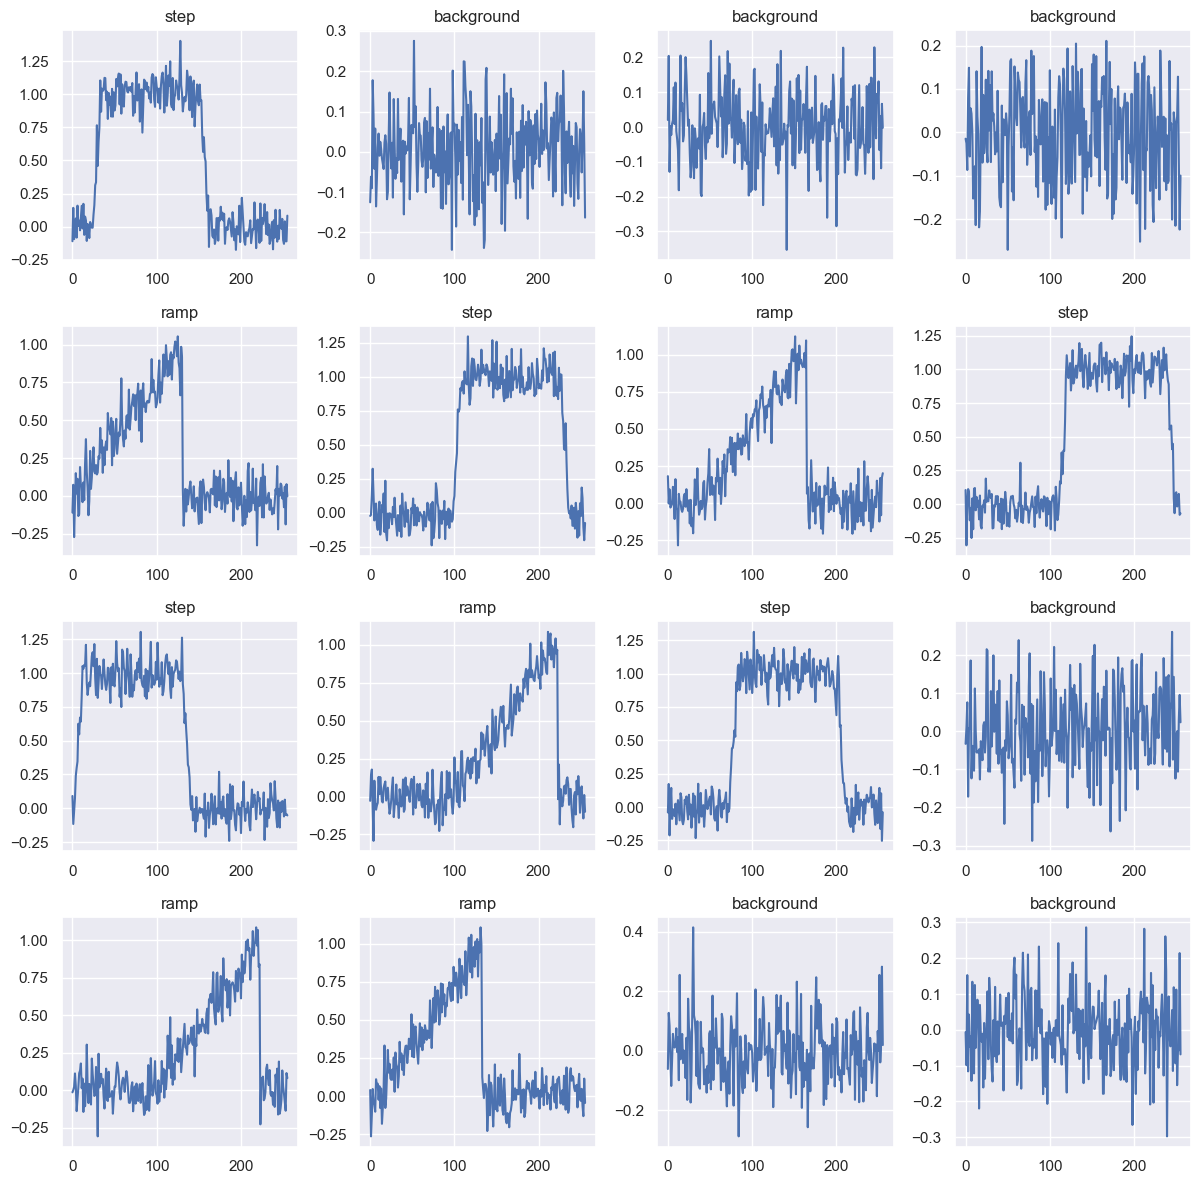

In [11]:
%matplotlib inline
visualizations.plot_labeled_samples_grid(tree, lambda sample, ax: sns.lineplot(sample, ax=ax));